In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
X = np.array([
    [1.0,1.0],
    [1.5,2.0],
    [3.0,4.0],
    [5.0,7.0],
    [3.5,5.0],
    [4.5,5.0],
    [3.5,4.5]
])


In [3]:
X.shape


(7, 2)

In [4]:
K=2


## Compute Euclidean Distance


In [5]:
def compute_distance(point, centroid):
  distance = np.linalg.norm(point-centroid, ord = 2)
  #distance = np.sqrt(np.sum((point - centroid)**2))
  return distance


In [6]:
point = np.array([3, 4])
centroid = np.array([1, 1])
print(compute_distance(point, centroid))


3.605551275463989


## K-Means++ Initialization
K-Means++ chooses the initial centroids so that points farther from existing centroids have a higher probability of being selected.


In [7]:
def kmeans_plus_plus(X, K):

    np.random.seed(42)
    
    # Select the first centroid randomly
    first_index = np.random.choice(len(X))
    centroids = [X[first_index]]

    for k in range(1, K):
        distances = []

        # Find squared distance from each point to its nearest centroid
        for point in X:
            point_distances = [np.sum((point - centroid)**2) for centroid in centroids]
            distances.append(min(point_distances))

        distances = np.array(distances)

        # Convert squared distances into probabilities
        probabilities = distances / np.sum(distances)

        # Select the next centroid according to these probabilities
        next_index = np.random.choice(len(X), p=probabilities)
        centroids.append(X[next_index])

    return np.array(centroids)


In [8]:
np.random.seed(1)
centroids = kmeans_plus_plus(X, K)
print(centroids)


[[3.5 4.5]
 [5.  7. ]]


## Find Closest Centroid


In [9]:
def find_closest_centroid(point, centroids):
    distances=np.linalg.norm(centroids-point, axis=1)
    index = np.argmin(distances)
    return index


In [10]:
print(find_closest_centroid(np.array([3,4]),centroids))


0


## Assign Clusters


In [11]:
def assign_clusters(X, centroids):
  idx = []
  for point in X:
    cluster = find_closest_centroid(point, centroids)
    idx.append(cluster)
  return np.array(idx)


In [12]:
idx=assign_clusters(X,centroids)
print(idx)


[0 0 0 1 0 0 0]


## Compute New Centroids



In [13]:
def compute_centroids(X, idx, K):
  new_centroids = []

  for k in range(K):
    points = X[idx == k]
    centroid = np.mean(points, axis=0)
    new_centroids.append(centroid)
  return np.array(new_centroids)


In [14]:
new_centroids=compute_centroids(X, idx, K)
print(new_centroids)


[[2.83333333 3.58333333]
 [5.         7.        ]]


## Compute Cost



In [15]:
def compute_cost(X, idx, centroids):
    m = len(X)
    total=0
    for i in range(m):
        centroid = centroids[idx[i]]
        total += np.sum((X[i] - centroid)**2)
    return total/m


In [16]:
print(compute_cost(X,idx,new_centroids))


3.291666666666667


## One Iteration


In [17]:
def run_iteration(X, centroids):
    idx=assign_clusters(X,centroids)
    new_centroids=compute_centroids(X,idx,len(centroids))
    cost=compute_cost(X,idx,new_centroids)
    return idx,new_centroids,cost


In [18]:
idx, new_centroids, cost = run_iteration(X, centroids)
print(idx)
print(new_centroids)
print(cost)


[0 0 0 1 0 0 0]
[[2.83333333 3.58333333]
 [5.         7.        ]]
3.291666666666667


## Complete K-Means



In [19]:
def run_kmeans(X, initial_centroids, max_iters=100):
    centroids=initial_centroids.copy()

    for i in range(max_iters):
        idx=assign_clusters(X,centroids)
        new_centroids=compute_centroids(X, idx, len(centroids))
        if np.allclose(new_centroids, centroids):
            break
        centroids=new_centroids
    return centroids,idx


In [20]:

initial_centroids = kmeans_plus_plus(X, K)
final_centroids, idx = run_kmeans(X,initial_centroids)
print(final_centroids)
print(idx)


[[1.25 1.5 ]
 [3.9  5.1 ]]
[0 0 1 1 1 1 1]


## Visualize


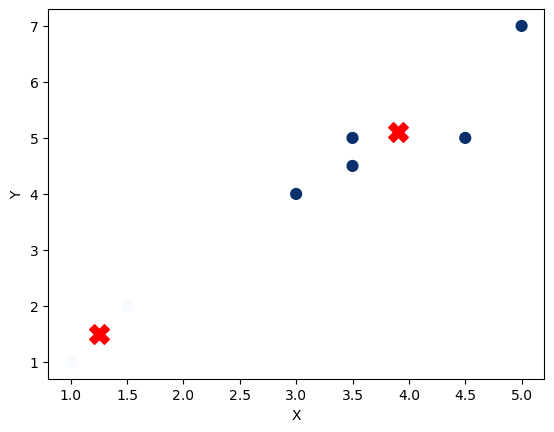

In [21]:
plt.scatter(X[:, 0],X[:, 1], c=idx, s=60, cmap='Blues')
plt.scatter(final_centroids[:,0],final_centroids[:,1],marker='X',color='red',s=200)

plt.xlabel("X")
plt.ylabel("Y")
plt.show()


## Elbow method


In [22]:
costs = []

for K in range(2, 5):

  # initialize centroids using K-Means++
  initial = kmeans_plus_plus(X, K)

  # get final centroids from K-Means
  centroids, idx = run_kmeans(X, initial, 200)

  # compute final cost between every point and its assigned centroid
  cost = compute_cost(X, idx, centroids)

  costs.append(cost)


In [23]:
print(costs)


[1.2178571428571427, 0.35714285714285715, 0.1845238095238095]


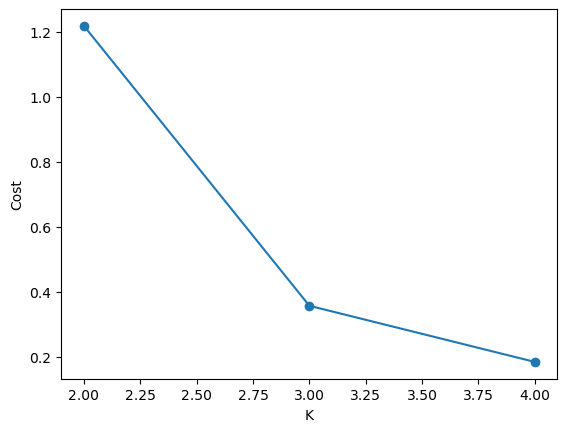

In [24]:
plt.plot(range(2, 5), costs, marker='o')
plt.xlabel("K")
plt.ylabel("Cost")
plt.show()
